# 144 — GRU 잔차 모델: 학습 곡선과 이력 가용성 4시나리오

수치 원본은 같은 폴더의 [`RESULTS.md`](./RESULTS.md)이고, 어긋나면 그쪽이 맞다. 이 노트북은
`evaluate_dl.py`가 남긴 지표 parquet과 아티팩트 `history.json`을 **그림으로만** 다시 읽는다.

질문은 하나다 — **이력이 짧거나 없을 때 모델이 lookup 아래로 떨어지는가.**
143에서 배포 LightGBM은 시차가 전부 NaN이면 lookup 대비 RMSE −37%였다. 144는 학습 때 이력을
무작위로 잘라(`masking.truncate_history`) "이력이 짧다"를 학습 분포 안에 넣으면 그 붕괴가 사라지는지를 본다.

In [1]:
import json
import sys
from pathlib import Path

AI_ROOT = Path.cwd()
while not (AI_ROOT / "app" / "CROWD").exists():
    AI_ROOT = AI_ROOT.parent
sys.path.insert(0, str(AI_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from DATA_ENGINE.eda import figstyle

figstyle.apply(inline=True)

GRU = AI_ROOT / "models/CROWD/dl_gru_s14_20260914-0949"
GRU_NT = AI_ROOT / "models/CROWD/dl_gru_s14_notrunc_20260914-0950"
LSTM = AI_ROOT / "models/CROWD/dl_lstm_s14_20260914-1236"
VAL = AI_ROOT / "data" / "CROWD" / "interim" / "validation"

metrics = pd.read_parquet(VAL / "dl_resid_metrics.parquet")
grades = pd.DataFrame(json.loads((VAL / "dl_resid_grades.json").read_text(encoding="utf-8")))
timing = json.loads((VAL / "dl_resid_timing.json").read_text(encoding="utf-8"))
meta = {p.name: json.loads((p / "meta.json").read_text(encoding="utf-8")) for p in (GRU, GRU_NT, LSTM)}
history = {p.name: pd.DataFrame(json.loads((p / "history.json").read_text(encoding="utf-8"))) for p in (GRU, GRU_NT, LSTM)}

SCEN = ["full", "d7_only", "d1_only", "no_lag"]
SERIES = ["lightgbm", "gru", "gru_no_trunc", "lstm"]
print(f"지표 {len(metrics):,}행 · 평가 행 {metrics['n'].max():,} · 하루치 CPU 추론 {timing['seconds']}s")
pd.DataFrame(
    [{"아티팩트": k, "증강": v["truncation"], "장치": v["device"], "epochs_run": v["epochs_run"],
       "best_epoch": v["best_epoch"], "best_valid": v["best_valid_loss"], "train_s": v["train_seconds"],
       "결정성_차이_%": v["determinism"]["rel_diff_pct"]} for k, v in meta.items()]
)

지표 416행 · 평가 행 1,992,900 · 하루치 CPU 추론 0.2s


,아티팩트,증강,장치,epochs_run,best_epoch,best_valid,train_s,결정성_차이_%
0,dl_gru_s14_20260914-0949,True,cuda,24,19,0.291675,88.9,0.0
1,dl_gru_s14_notrunc_20260914-0950,False,cuda,21,16,0.290287,77.9,0.0
2,dl_lstm_s14_20260914-1236,True,cuda,24,19,0.292061,81.8,0.0


## 1. 학습 곡선

`valid`는 **절단 없는 full 이력**, `valid(절단)`은 학습과 같은 분포로 이력을 무작위로 자른 검증 손실이다.
둘을 같이 봐야 "증강이 무엇을 바꿨는지"가 보인다 — full은 거의 그대로고 절단 쪽만 갈린다.

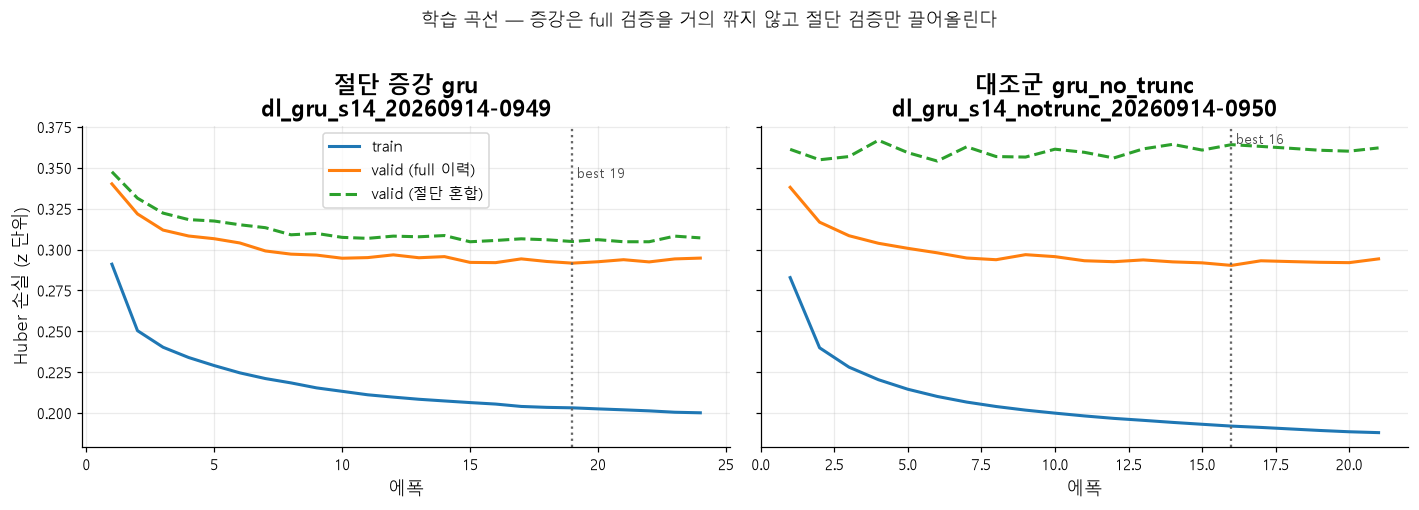

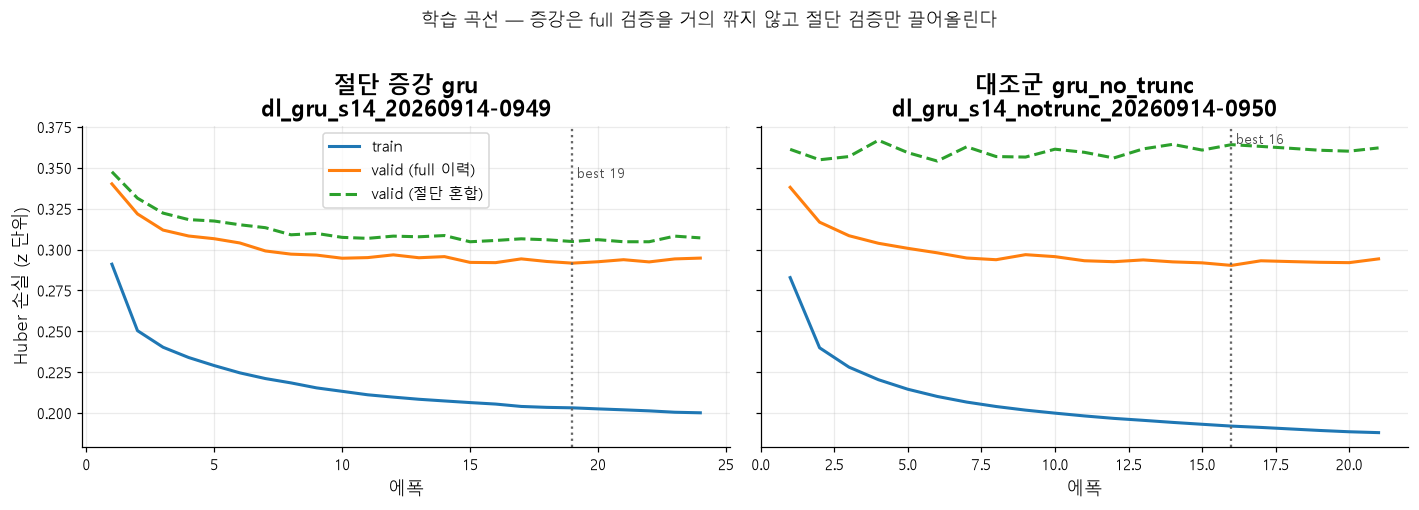

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, (name, h) in zip(axes, list(history.items())[:2]):
    ax.plot(h["epoch"], h["train_loss"], label="train", lw=2)
    ax.plot(h["epoch"], h["valid_loss"], label="valid (full 이력)", lw=2)
    ax.plot(h["epoch"], h["valid_loss_trunc"], label="valid (절단 혼합)", lw=2, ls="--")
    best = meta[name]["best_epoch"]
    ax.axvline(best, color="0.4", ls=":", lw=1.5)
    ax.annotate(f"best {best}", (best, ax.get_ylim()[1]), xytext=(3, -12),
                textcoords="offset points", fontsize=9, color="0.3")
    ax.set_title(("절단 증강 gru" if meta[name]["truncation"] else "대조군 gru_no_trunc") + f"\n{name}")
    ax.set_xlabel("에폭")
axes[0].set_ylabel("Huber 손실 (z 단위)")
axes[0].legend()
fig.suptitle("학습 곡선 — 증강은 full 검증을 거의 깎지 않고 절단 검증만 끌어올린다", y=1.02)
fig.tight_layout()
fig

## 2. 이력 가용성 4시나리오 — lookup 대비 개선율

0선(lookup)이 기준이다. **아래로 내려간 막대는 "차라리 평균을 쓰는 게 나았다"**는 뜻이다.

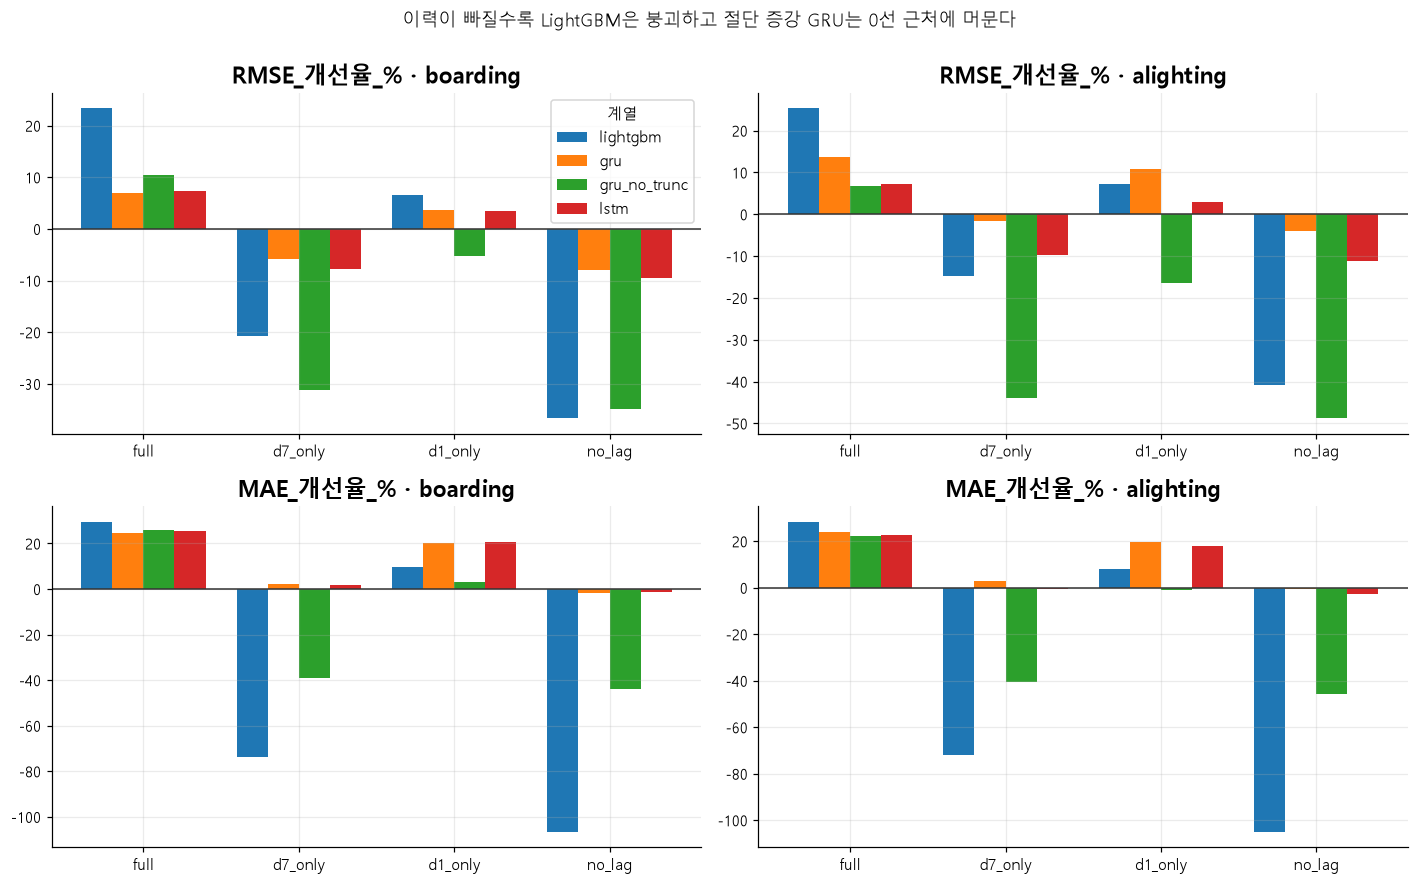

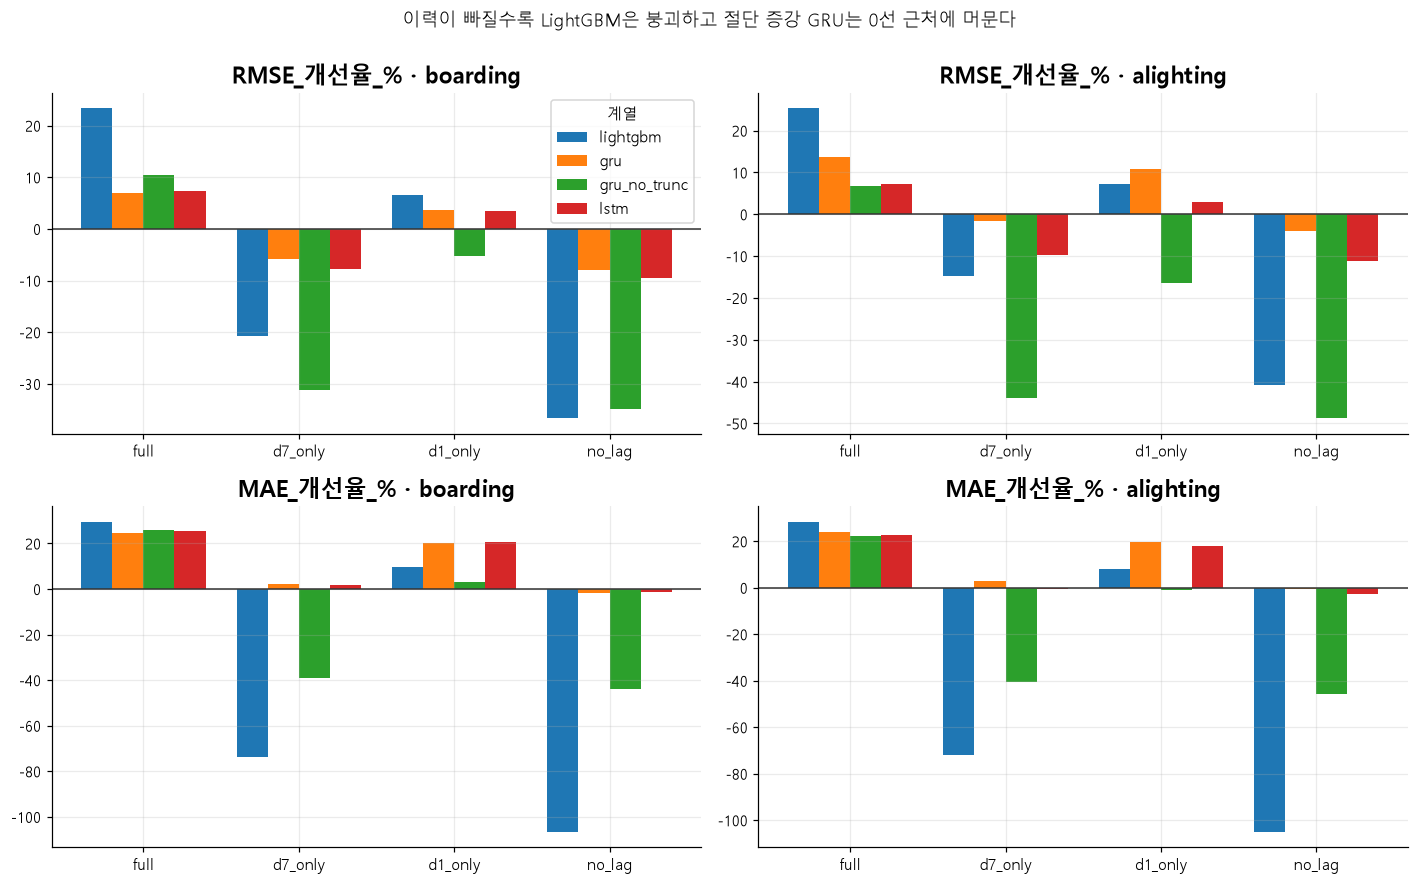

In [3]:
tot = metrics[metrics["axis"] == "전체"]

def bars(metric, ax, target):
    piv = tot[tot["target"] == target].pivot_table(index="scenario", columns="series", values=metric)
    piv = piv.reindex(index=SCEN, columns=SERIES)
    x = np.arange(len(SCEN))
    w = 0.2
    for i, s in enumerate(SERIES):
        ax.bar(x + (i - 1.5) * w, piv[s], w, label=s)
    ax.axhline(0, color="0.2", lw=1)
    ax.set_xticks(x, SCEN)
    ax.set_title(f"{metric} · {target}")
    return piv

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for row, metric in enumerate(["RMSE_개선율_%", "MAE_개선율_%"]):
    for col, target in enumerate(["boarding", "alighting"]):
        bars(metric, axes[row][col], target)
axes[0][0].legend(title="계열")
fig.suptitle("이력이 빠질수록 LightGBM은 붕괴하고 절단 증강 GRU는 0선 근처에 머문다", y=1.0)
fig.tight_layout()
fig

In [4]:
tot[tot["target"] == "boarding"].pivot_table(
    index="series", columns="scenario", values=["RMSE_개선율_%", "MAE_개선율_%", "rmse", "mae"]
).round(2).reindex(SERIES)

MAE_개선율_%                        RMSE_개선율_%                 \
scenario       d1_only d7_only   full  no_lag    d1_only d7_only   full   
series                                                                    
lightgbm          9.46  -73.81  29.56 -106.47       6.52  -20.79  23.38   
gru              20.01    2.02  24.68   -1.54       3.60   -5.78   6.99   
gru_no_trunc      3.04  -39.23  25.73  -43.95      -5.24  -31.16  10.38   
lstm             20.73    1.59  25.26   -1.14       3.55   -7.79   7.31   

                        mae                           rmse                  \
scenario     no_lag d1_only d7_only   full  no_lag d1_only d7_only    full   
series                                                                       
lightgbm     -36.63   74.17  142.37  57.70  169.13  183.31  236.88  150.25   
gru           -7.92   65.53   80.26  61.69   83.17  189.05  207.44  182.40   
gru_no_trunc -34.89   79.42  114.05  60.84  117.92  206.38  257.20  175.75   
lstm          -9.43   64.94   80.62  61.22   82.85  189.13  211.38  181.77   

                      
scenario      no_lag  
series                
lightgbm      267.94  
gru           211.62  
gru_no_trunc  264.52  
lstm          214.59

## 3. 등급 일치율 — 서비스가 실제로 보여주는 값

승하차 RMSE 격차가 등급(임계치 50/100, 30분 셀 716만 개)까지 전달되는지 본다.
`full`에서는 세 계열이 사실상 같고, 이력이 빠지면 GRU만 lookup 수준을 지킨다.

series,lightgbm,gru,gru_no_trunc,lstm
scenario,,,,
full,96.619,96.695,96.682,96.663
d7_only,92.347,95.517,93.201,95.486
d1_only,95.654,96.455,95.267,96.434
no_lag,91.494,95.339,92.970,95.346


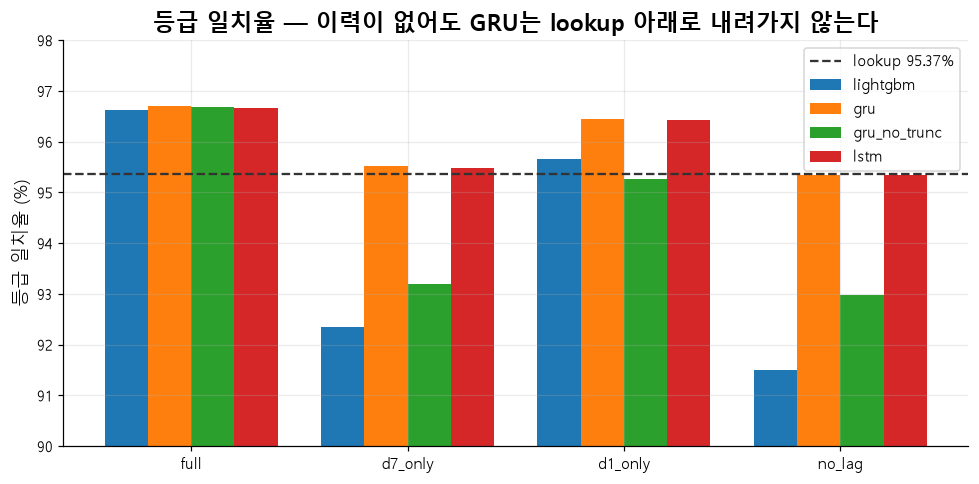

In [5]:
g = grades[grades["run"] != "lookup"].copy()
g[["series", "scenario"]] = g["run"].str.split("|", expand=True)
piv = g.pivot_table(index="scenario", columns="series", values="등급_일치율_%").reindex(
    index=SCEN, columns=SERIES
)
base = float(grades.loc[grades["run"] == "lookup", "등급_일치율_%"].iloc[0])

fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(SCEN))
for i, s in enumerate(SERIES):
    ax.bar(x + (i - 1.5) * 0.2, piv[s], 0.2, label=s)
ax.axhline(base, color="0.2", ls="--", lw=1.5, label=f"lookup {base:.2f}%")
ax.set_xticks(x, SCEN)
ax.set_ylim(90, 98)
ax.set_ylabel("등급 일치율 (%)")
ax.set_title("등급 일치율 — 이력이 없어도 GRU는 lookup 아래로 내려가지 않는다")
ax.legend()
fig.tight_layout()
piv.round(3)

## 4. 호선·요일유형 슬라이스

`full`에서 GRU가 lookup보다 나쁜 유일한 호선이 2호선(순환선·지선 방향 체계)이고, LSTM은 더 나쁘다(−8.98).
반대로 8·4호선처럼 규모가 작은 호선에서는 GRU가 LightGBM을 앞선다.

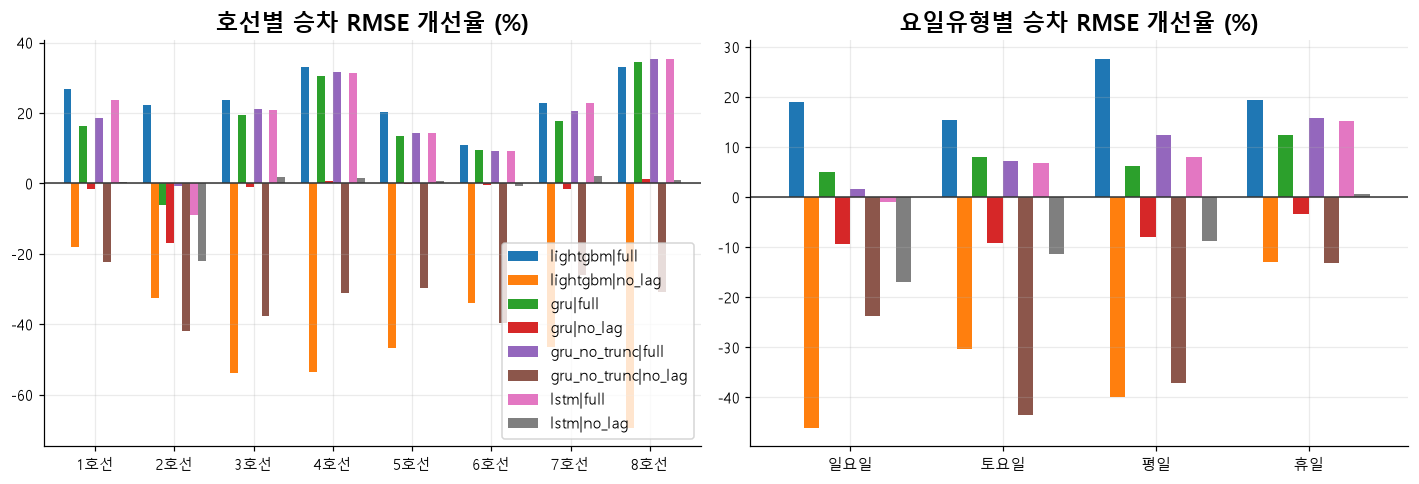

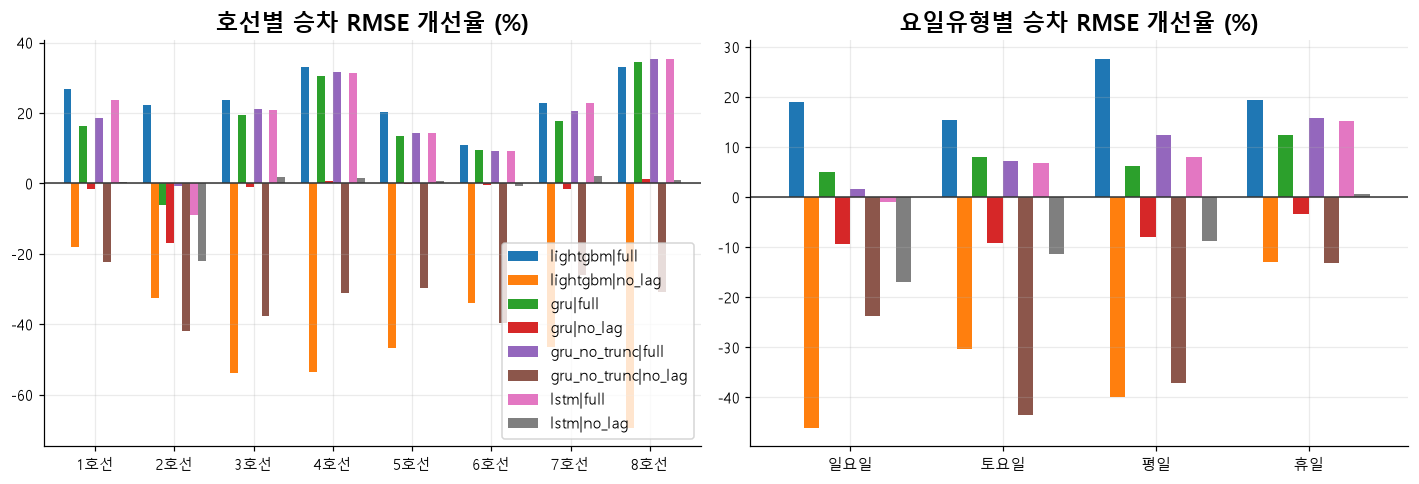

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, (axis, title) in zip(axes, [("line", "호선별"), ("day_type", "요일유형별")]):
    sub = metrics[(metrics["axis"] == axis) & (metrics["target"] == "boarding")
                  & (metrics["scenario"].isin(["full", "no_lag"]))]
    piv = sub.pivot_table(index="group", columns=["series", "scenario"], values="RMSE_개선율_%")
    piv = piv.reindex(columns=[(s, sc) for s in SERIES for sc in ("full", "no_lag")])
    piv.columns = [f"{s}|{sc}" for s, sc in piv.columns]
    piv.plot.bar(ax=ax, width=0.8, legend=(axis == "line"))
    ax.axhline(0, color="0.2", lw=1)
    ax.set_title(f"{title} 승차 RMSE 개선율 (%)")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0)
fig.tight_layout()
fig

## 5. 읽은 것

1. **`full`에서 GRU는 LightGBM에 RMSE로 크게 진다**(+6.99 vs +23.38, 승차). 판정 기준 (a)(±2%p) 불충족.
   반면 MAE 격차는 5%p 안쪽이고 등급 일치율은 동등하다 — RMSE 격차는 대형 이상치를 못 따라가는 데서 온다.
2. **이력이 빠지면 순위가 뒤집힌다.** `no_lag`에서 LightGBM −36.6%, 대조군 GRU −34.9%, 절단 증강 GRU −7.9%.
   등급으로 보면 절단 증강 GRU만 lookup과 같다(95.34 vs 95.37). 기준 (b)는 "0%p 이상"에는 못 미쳤지만
   **붕괴하지 않는다**는 성질은 확인됐다.
3. **절단 증강의 대가는 작다.** 두 모델의 full 검증 손실은 0.2917 vs 0.2903으로 거의 같고, 2025 `full`에서는
   승차 −3.4%p / 하차 +7.0%p로 방향이 엇갈린다 — 시드 1개로는 (c)를 판정할 수 없다(145에서 시드 반복).
4. **LSTM(1회 실험)은 GRU와 구분되지 않는다.** 검증 손실 0.2921 vs 0.2917(0.13% 차), `full`은 승차 +7.31 vs +6.99·하차 +7.12 vs +13.72, `no_lag`은 GRU가 낫다. 계열 이름은 `gru`로 확정하고 LSTM은 기록용 1행으로 닫는다.
5. **CPU 하루치 추론 0.2초.** 운영 기준(10분) 대비 문제가 되지 않는다.

다음(145): 판정 지표 확정, 가용성별 예측기 3단 선택(LightGBM / GRU / lookup), 손실·정규화 1파라미터 실험,
2호선 열세 원인. 미해결 목록 전체는 [`RESULTS.md`](./RESULTS.md) 5절.